In [182]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dhruvbchokshi/linear-regression-2b/breast-cancer.csv


In [183]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pprint
import pickle

In [184]:
import os
os.listdir('/kaggle/input')
os.listdir('/kaggle/input/datasets/dhruvbchokshi/linear-regression-2b')

['breast-cancer.csv']

In [185]:
df = pd.read_csv('/kaggle/input/datasets/dhruvbchokshi/linear-regression-2b/breast-cancer.csv')

In [186]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [187]:
px.histogram(data_frame=df, x='diagnosis', color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [188]:
px.histogram(data_frame=df,x='area_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [189]:
px.histogram(data_frame=df,x='radius_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [190]:
px.histogram(data_frame=df,x='perimeter_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [191]:
px.histogram(data_frame=df,x='smoothness_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [192]:
px.histogram(data_frame=df,x='texture_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [193]:
px.scatter(data_frame=df,x='symmetry_worst',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [194]:
px.scatter(data_frame=df,x='concavity_worst',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [195]:
px.scatter(data_frame=df,x='fractal_dimension_worst',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [196]:
df.drop('id', axis=1, inplace=True)

In [197]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [198]:
corr = df.corr()

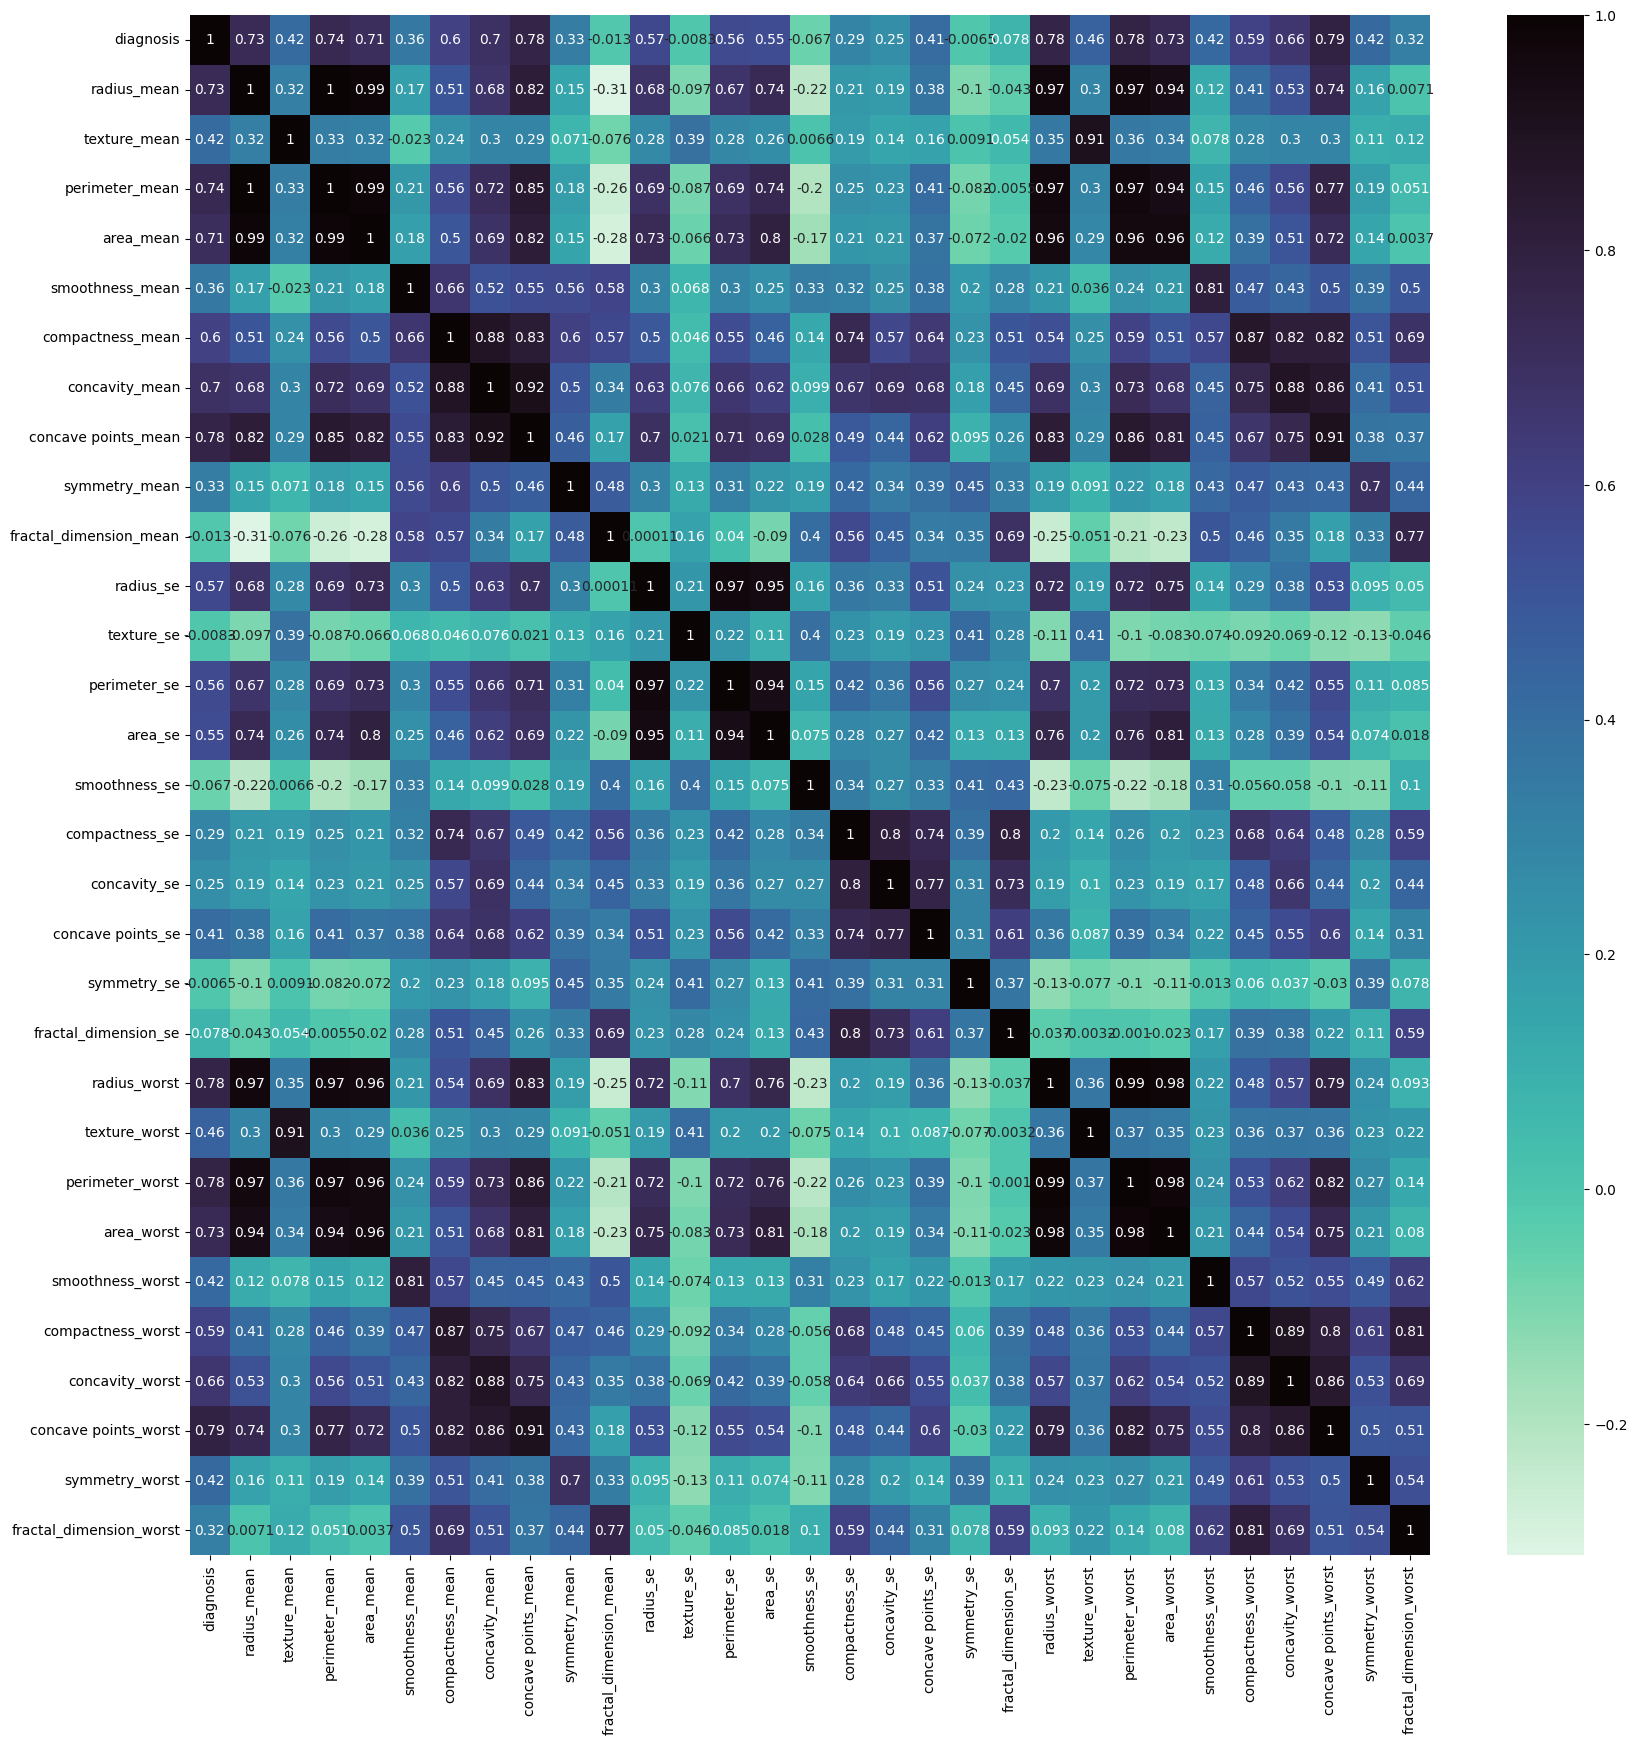

In [199]:
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='mako_r', annot=True)
plt.show()

In [200]:
cor_target = abs(corr['diagnosis'])

In [201]:
relevant_features = cor_target[cor_target > 0.2]

In [202]:
names = relevant_features.index

In [203]:
names = names.drop('diagnosis')

In [204]:
pprint.pprint(names)

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'radius_se', 'perimeter_se',
       'area_se', 'compactness_se', 'concavity_se', 'concave points_se',
       'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'smoothness_worst', 'compactness_worst', 'concavity_worst',
       'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [205]:
X = df[names].values
y = df['diagnosis'].values

In [206]:
def train_test_split(X, y, random_state=42, test_size=0.2):

    # Get number of samples
    n_samples = X.shape[0]

    # Set random seed
    np.random.seed(random_state)

    # Shuffle indices
    shuffled_indices = np.random.permutation(n_samples)

    # Determine test size
    test_size = int(n_samples * test_size)

    # Split indices
    test_indices = shuffled_indices[:test_size]
    train_indices = shuffled_indices[test_size:]

    # Split data
    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test

In [207]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [208]:
def standardize_data(X_train, X_test):

    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    std[std == 0] = 1  # avoid division by zero

    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std

    return X_train, X_test

In [209]:
def sigmoid(z):
    sigmoid_result = 1 / (1 + np.exp(-z))
    return sigmoid_result

In [210]:
z = np.linspace(-12, 12, 200)

fig = px.line(x=z, y=sigmoid(z),title='Logistic Function',template="plotly_dark")
fig.update_layout(
    title_font_color="#41BEE9", 
    xaxis=dict(color="#41BEE9"), 
    yaxis=dict(color="#41BEE9") 
)
fig.show()


In [211]:
class LogisticRegression:
    
    def __init__(self, learning_rate=0.0001):
        np.random.seed(1)
        self.learning_rate = learning_rate

    def initialize_parameter(self):
        # initialize weights and bias
        self.w = np.zeros(self.X.shape[1])
        self.b = 0.0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        Z = np.matmul(X, self.w) + self.b
        A = self.sigmoid(Z)
        return A

    def compute_cost(self, predictions):
        m = self.X.shape[0]

        cost = np.sum(
            -np.log(predictions + 1e-8) * self.y +
            -np.log(1 - predictions + 1e-8) * (1 - self.y)
        )

        cost = cost / m
        return cost

    def compute_gradient(self, predictions):
        m = self.X.shape[0]

        error = predictions - self.y

        # gradients
        self.dw = np.dot(self.X.T, error) / m
        self.db = np.sum(error) / m

    def fit(self, X, y, iterations, plot_cost=True):
        self.X = X
        self.y = y

        self.initialize_parameter()

        costs = []

        for i in range(iterations):

            # forward pass
            predictions = self.forward(self.X)

            # cost
            cost = self.compute_cost(predictions)
            costs.append(cost)

            # gradients
            self.compute_gradient(predictions)

            # update
            self.w = self.w - self.learning_rate * self.dw
            self.b = self.b - self.learning_rate * self.db

            if i % 10000 == 0:
                print(f"Cost after iteration {i}: {cost}")

        # plot cost
        if plot_cost:
            import plotly.express as px
            fig = px.line(y=costs, title="Cost vs Iteration", template="plotly_dark")
            fig.show()

    def predict(self, X):
        Z = np.matmul(X, self.w) + self.b
        A = self.sigmoid(Z)

        return (A >= 0.5).astype(int)

    def save_model(self, filename=None):
        model_data = {
            'learning_rate': self.learning_rate,
            'w': self.w,
            'b': self.b
        }

        with open(filename, 'wb') as file:
            pickle.dump(model_data, file)

    @classmethod
    def load_model(cls, filename):
        with open(filename, 'rb') as file:
            model_data = pickle.load(file)

        loaded_model = cls(model_data['learning_rate'])
        loaded_model.w = model_data['w']
        loaded_model.b = model_data['b']

        return loaded_model

In [212]:
print(X_train.shape)
print(y_train.shape)

(456, 25)
(456,)


In [213]:
lg = LogisticRegression()
lg.fit(X_train, y_train,100000)

Cost after iteration 0: 0.6931471605599454
Cost after iteration 10000: 0.3124083101210189
Cost after iteration 20000: 0.29853577346322796
Cost after iteration 30000: 0.29190572846341933
Cost after iteration 40000: 0.2630504124336952
Cost after iteration 50000: 0.26517603322479705
Cost after iteration 60000: 0.25881203634124866
Cost after iteration 70000: 0.23675196371727056
Cost after iteration 80000: 0.23697057604371277
Cost after iteration 90000: 0.24217579669854727


In [214]:
lg.save_model("model.pkl")

In [215]:
class ClassificationMetrics:

    @staticmethod
    def accuracy(y_true, y_pred):
        return np.mean(y_true == y_pred)


    @staticmethod
    def precision(y_true, y_pred):
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        
        if TP + FP == 0:
            return 0
        
        return TP / (TP + FP)


    @staticmethod
    def recall(y_true, y_pred):
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FN = np.sum((y_pred == 0) & (y_true == 1))
        
        if TP + FN == 0:
            return 0
        
        return TP / (TP + FN)


    @staticmethod
    def f1_score(y_true, y_pred):
        precision = ClassificationMetrics.precision(y_true, y_pred)
        recall = ClassificationMetrics.recall(y_true, y_pred)
        
        if precision + recall == 0:
            return 0
        
        return 2 * (precision * recall) / (precision + recall)

In [216]:
model = LogisticRegression.load_model("model.pkl")

y_pred = model.predict(X_test)

accuracy = ClassificationMetrics.accuracy(y_test, y_pred)
precision = ClassificationMetrics.precision(y_test, y_pred)
recall = ClassificationMetrics.recall(y_test, y_pred)
f1_score = ClassificationMetrics.f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1-Score: {f1_score:.2%}")

Accuracy: 95.58%
Precision: 95.12%
Recall: 92.86%
F1-Score: 93.98%
